# Regression Models, Built From Scratch
### A hands-on handout — 8 real machine learning models, one real dataset, zero Python assumed

---

**What this is.** Not a lecture. You are going to build eight working regression
models, one after another, each one fixing a problem the previous one had. By the
last cell you will have eight saved model files and a program that prices a house.

**What you need to know before starting.** Nothing. Section 2 is a twelve-minute
Python survival kit that covers every piece of Python used in this notebook.

**The data is real.** 2,930 actual house sales in Ames, Iowa, recorded by the city
assessor's office between 2006 and 2010. It was published by Dean De Cock in the
*Journal of Statistics Education* (2011) as a modern replacement for the old Boston
housing dataset, and it is the basis of Kaggle's most popular regression competition.
Nothing here is invented.

**How to read it.** Every code cell is followed by a plain-English explanation of
what just happened. Run the cells in order, top to bottom — later cells depend on
earlier ones. If something breaks, restart the kernel and run again from the top.

---

## The map

| # | Model | The problem it solves |
|---|-------|----------------------|
| 1 | **Simple linear regression** | Draw one straight line through one feature |
| — | **MAE / MSE / RMSE / R²** | How do we know if a model is any good? |
| 2 | **Multiple linear regression** | One feature isn't enough — use twenty |
| 3 | **Polynomial regression** | Some relationships bend; straight lines can't |
| 4 | **Ridge** | Bending too much = memorising. Punish complexity |
| 5 | **Lasso** | Punish complexity *and* delete useless features |
| 6 | **Elastic Net** | Ridge and Lasso, blended |
| 7 | **SVR** | Stop chasing every point; fit a tube instead |
| 8 | **Decision Tree** | Forget equations — ask yes/no questions |
| 9 | **Random Forest** | One tree is unreliable. Ask 300 of them |

(That's nine boxes for eight ideas — Ridge, Lasso and Elastic Net are three flavours
of the same one idea, regularisation.)

---
# Part 1 — Why regression exists at all

Here is the entire problem in one sentence:

> **You know some things about a house. You want to know its price. Regression is
> the machine that turns the first into the second.**

The things you know are called **features** (size, year built, neighbourhood). The
thing you want is called the **target** (price). Regression learns the relationship
between them from thousands of past sales, then applies that relationship to a house
it has never seen.

**Why is this "machine learning" and not just a formula?** Because nobody writes the
formula. You hand the machine 2,000 past sales and it *finds* the formula itself, by
trying values and keeping the ones that produce the smallest error. That search is
the "learning".

**Regression vs. classification.** Regression predicts a *number* on a continuous
scale — a price, a temperature, a delivery time, a blood pressure, next month's
revenue. Classification predicts a *category* — spam or not spam, cat or dog. This
whole notebook is regression. Same toolbox, different question.

**Where you'll actually use it:** demand forecasting, pricing, credit risk scoring,
estimating time-to-completion, dosage response in medicine, ad spend → revenue
attribution. If the answer is a number, you are in this notebook's territory.

One thing to get straight now, because it separates people who understand ML from
people who quote it:

> **A model that is perfect on the data it was trained on is usually worthless.**

The only score that means anything is the score on houses the model has *never seen*.
Section 5 makes this concrete, and it is the single most important idea here.

---
# Part 2 — The twelve-minute Python survival kit

Everything below is every piece of Python this notebook uses. If you understand these
six cells you can read the whole thing. Run each one and look at what it prints.

In [1]:
# A "variable" is a name pinned to a value. The = sign means "store this under that name".
price = 250000
city = "Ames"
sizes = [1200, 1500, 2100]        # a list: several values in order, in square brackets

# print() displays something. The f"..." lets you drop variables inside text using { }.
print(f"A house in {city} sold for ${price:,}")
print(f"The list has {len(sizes)} entries and the first one is {sizes[0]}")

A house in Ames sold for $250,000
The list has 3 entries and the first one is 1200


**What happened.** `price = 250000` stores a number. `sizes = [...]` stores a *list*.
`len(sizes)` counts the entries. `sizes[0]` grabs the first one — Python counts from
**0**, not 1, so the first item is number 0. That trips up everybody once.
The `:,` inside `{price:,}` is just formatting: it inserts thousands separators.

In [2]:
# A "function" is a saved recipe. def creates one. It takes inputs and returns an output.
def price_per_sqft(total_price, square_feet):
    return total_price / square_feet          # / is division

# "Calling" the function = running the recipe with real inputs.
result = price_per_sqft(250000, 1500)
print(f"${result:.2f} per square foot")       # :.2f means "show 2 decimal places"

$166.67 per square foot


**What happened.** `def` defines a function called `price_per_sqft` that expects two
inputs. `return` hands the answer back. You will barely write functions in this
notebook, but you will *call* other people's functions constantly — every
`something(...)` you see below is a function call.

In [3]:
# You don't write machine learning from scratch. You import libraries other people built.
import pandas as pd                    # pandas = tables of data. "pd" is its nickname.
import numpy as np                     # numpy  = fast maths on lists of numbers
import matplotlib.pyplot as plt        # matplotlib = charts

print("pandas version:", pd.__version__)
print("numpy  version:", np.__version__)

pandas version: 3.0.5
numpy  version: 2.5.2


**What happened.** `import pandas as pd` loads the pandas library and gives it the
short name `pd`, so you can type `pd.read_csv(...)` instead of
`pandas.read_csv(...)`. These nicknames (`pd`, `np`, `plt`) are universal conventions —
every Python data notebook on earth uses exactly these three.

In [4]:
# A DataFrame is a spreadsheet living inside Python. Rows and named columns.
demo = pd.DataFrame({
    "size":  [1200, 1500, 2100, 900],
    "price": [180000, 215000, 310000, 140000],
})
demo                                    # the last line of a cell displays itself

,size,price
0,1200,180000
1,1500,215000
2,2100,310000
3,900,140000


**What happened.** `pd.DataFrame({...})` built a small table from a dictionary
(`{"column name": [values...]}`). Notice the last line has no `print()` — in a
notebook, whatever the final line evaluates to gets displayed automatically, and
for a DataFrame that means a nicely formatted table.

In [5]:
# Grabbing parts of a table — the three moves you need:
print("One column:")
print(demo["size"])                     # square brackets + the column name in quotes

print("\nTwo columns (note the DOUBLE brackets):")
print(demo[["size", "price"]])          # a LIST of names inside the brackets

print("\nOnly the big houses:")
print(demo[demo["size"] > 1400])        # a condition inside the brackets = filter rows

One column:
0    1200
1    1500
2    2100
3     900
Name: size, dtype: int64

Two columns (note the DOUBLE brackets):
   size   price
0  1200  180000
1  1500  215000
2  2100  310000
3   900  140000

Only the big houses:
   size   price
1  1500  215000
2  2100  310000


**What happened.** Three things, and they cover 90% of the data handling in this
notebook:

- `demo["size"]` → one column.
- `demo[["size", "price"]]` → several columns. **Double brackets** because you are
  passing a *list* of names. Forgetting the second pair of brackets is the most
  common beginner error in pandas.
- `demo[demo["size"] > 1400]` → keeps only rows where the condition is true.

The `\n` inside the quotes just prints a blank line.

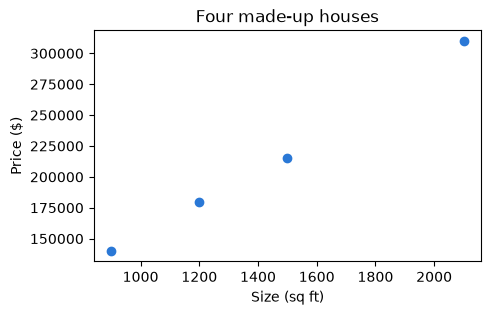

In [6]:
# One chart, so the plotting syntax isn't a surprise later.
plt.figure(figsize=(5, 3))                                  # make a canvas 5x3 inches
plt.scatter(demo["size"], demo["price"], color="#2a78d6")   # x values, y values, colour
plt.xlabel("Size (sq ft)")                                  # label the horizontal axis
plt.ylabel("Price ($)")                                     # label the vertical axis
plt.title("Four made-up houses")
plt.show()                                                  # draw it

**What happened.** `plt.scatter(x, y)` puts a dot at each pair of values. The rest is
labelling. Every chart in this notebook is this same handful of commands with more
lines added. That is the whole survival kit — you now know enough Python to read
everything that follows.

---
# Part 3 — Meet the data

2,930 real house sales. Let's open the file and look at it before we model anything.
Skipping this step is how people build confident models on broken data.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Chart styling, set once so every chart in the notebook matches.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8985", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
VIOLET, RED, GREEN, PINK = "#4a3aa7", "#e34948", "#008300", "#e87ba4"

ames = pd.read_csv("data/ames.csv")     # read the file into a DataFrame

print(f"Rows (houses):   {ames.shape[0]:,}")
print(f"Columns (facts): {ames.shape[1]}")

Rows (houses):   2,930
Columns (facts): 82


**What happened.** `pd.read_csv` loaded the file. `.shape` reports `(rows, columns)`,
so `.shape[0]` is the row count and `.shape[1]` the column count. 2,930 houses
described by 82 different facts each.

The `plt.rcParams.update({...})` block is pure cosmetics — it sets the default look
of every chart so we don't repeat styling code twenty times.

In [8]:
# Look at a few real rows, a few interesting columns.
ames[["Gr Liv Area", "Year Built", "Overall Qual", "Neighborhood", "SalePrice"]].head()

,Gr Liv Area,Year Built,Overall Qual,Neighborhood,SalePrice
0,1656,1960,6,NAmes,215000
1,896,1961,5,NAmes,105000
2,1329,1958,6,NAmes,172000
3,2110,1968,7,NAmes,244000
4,1629,1997,5,Gilbert,189900


**What happened.** `.head()` shows the first 5 rows. Reading the columns:

- **Gr Liv Area** — "Ground Living Area", the above-ground living space in square feet.
  This is the single most important number about a house.
- **Year Built** — the year of construction.
- **Overall Qual** — the assessor's 1–10 rating of materials and finish.
- **Neighborhood** — one of 28 districts in Ames.
- **SalePrice** — what it actually sold for, in dollars. **This is our target.**

Note the column names have *spaces* in them. That's why we always write
`ames["Gr Liv Area"]` with brackets and quotes.

In [9]:
# What do prices actually look like?
print(ames["SalePrice"].describe().round(0))

count      2930.0
mean     180796.0
std       79887.0
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0
Name: SalePrice, dtype: float64


**What happened.** `.describe()` computes eight summary statistics at once.
Read them like this:

- **count 2930** — no house is missing a price. Good.
- **mean \$180,796** — the average sale.
- **std \$79,887** — the "standard deviation", i.e. how spread out prices are. Big
  number → prices vary a lot → there is something worth predicting.
- **min \$12,789 / max \$755,000** — a 59× range. Ames has shacks and mansions.
- **25% / 50% / 75%** — a quarter of houses sold below \$129,500, half below
  \$160,000, three quarters below \$213,500.

That gap between the mean (\$180,796) and the median (\$160,000) tells you the
distribution leans right: a handful of expensive houses drag the average up. Let's see it.

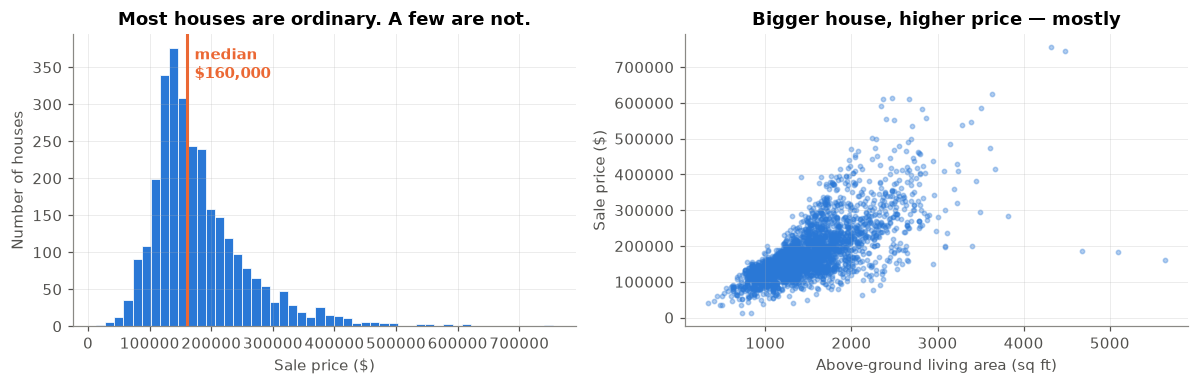

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ames["SalePrice"], bins=50, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].axvline(ames["SalePrice"].median(), color=ORANGE, linewidth=2)
axes[0].text(ames["SalePrice"].median()*1.08, axes[0].get_ylim()[1]*0.85,
             f"median\n${ames['SalePrice'].median():,.0f}", color=ORANGE, fontweight="bold")
axes[0].set_xlabel("Sale price ($)"); axes[0].set_ylabel("Number of houses")
axes[0].set_title("Most houses are ordinary. A few are not.")

axes[1].scatter(ames["Gr Liv Area"], ames["SalePrice"], s=8, alpha=0.35, color=BLUE)
axes[1].set_xlabel("Above-ground living area (sq ft)"); axes[1].set_ylabel("Sale price ($)")
axes[1].set_title("Bigger house, higher price — mostly")

plt.tight_layout(); plt.show()

**What happened.** `plt.subplots(1, 2, ...)` made one figure with two charts side by
side; `axes[0]` is the left one, `axes[1]` the right. `.hist()` draws a histogram
(bars counting how many houses fall in each price band), `.axvline()` draws a
vertical line, `.scatter()` draws dots. `alpha=0.35` makes dots translucent so you can
see where they pile up.

**What it tells us.** The right-hand chart is the entire premise of this notebook:
the dots trend upward. Size carries real information about price. That upward trend
is what a model *learns*.

But look at the bottom-right corner — a few enormous houses that sold cheap. Those
are real, and they are a problem.

In [11]:
# Dean De Cock, who published this dataset, explicitly recommends removing these.
outliers = ames[ames["Gr Liv Area"] > 4000]
print(outliers[["Gr Liv Area", "Overall Qual", "Sale Condition", "SalePrice"]])

      Gr Liv Area  Overall Qual Sale Condition  SalePrice
1498         5642            10        Partial     160000
1760         4476            10        Abnorml     745000
1767         4316            10         Normal     755000
2180         5095            10        Partial     183850
2181         4676            10        Partial     184750


**What happened.** We filtered to houses over 4,000 sq ft. There are five. Look at the
`Sale Condition` column: three say **Partial**, meaning the home wasn't finished when
it sold — so an enormous house went for a fraction of its value. These aren't normal
market transactions, and teaching a model on them poisons it.

This is a real judgement call, not a formality: you are throwing away data. The reason
it's defensible here is that the dataset's own author documented these five as
unrepresentative. "The outlier looks weird to me" is *not* a reason to delete a row.

In [12]:
houses = ames[ames["Gr Liv Area"] <= 4000].copy()   # .copy() = work on a fresh copy
print(f"Before: {len(ames):,} houses")
print(f"After:  {len(houses):,} houses  ({len(ames) - len(houses)} removed)")

Before: 2,930 houses
After:  2,925 houses  (5 removed)


**What happened.** We kept every house at or under 4,000 sq ft and stored the result
in a new table called `houses`. From here on, `houses` is our working dataset and
`ames` is left untouched as the original. `.copy()` avoids a pandas warning about
modifying a slice of another table — just always add it when filtering.

---
# Part 4 — Model 1: Simple Linear Regression

### The idea in one sentence
**Draw the single straight line that comes closest to all the dots.**

That's it. That is the entire algorithm. A straight line is described by two numbers:

```
price  =  b  +  m x size
```

- **m** (the *slope*, or *coefficient*) — how many dollars each extra square foot adds.
- **b** (the *intercept*) — where the line crosses zero. Often not physically meaningful.

There are infinitely many lines you could draw. The algorithm picks the one where the
total vertical distance from the dots to the line is smallest. Specifically it minimises
the sum of *squared* distances — hence the method's real name, **Ordinary Least Squares**.

Why squared? Two reasons: squaring makes every error positive (so errors above and below
the line don't cancel out), and it punishes one huge miss far more than several small
ones. That second property matters, and we'll come back to it.

In [13]:
from sklearn.linear_model import LinearRegression

# X = what the model sees (features). Double brackets = a table, even for one column.
# y = what the model must predict (the target). Single brackets = one column.
X_simple = houses[["Gr Liv Area"]]
y = houses["SalePrice"]

model_1 = LinearRegression()      # 1. create an empty, untrained model
model_1.fit(X_simple, y)          # 2. show it the data — this is the "learning"

slope = model_1.coef_[0]
intercept = model_1.intercept_
print(f"Slope     (m): ${slope:,.2f} per extra square foot")
print(f"Intercept (b): ${intercept:,.0f}")

Slope     (m): $116.23 per extra square foot
Intercept (b): $6,773


**What happened.** Three lines did all the work:

1. `LinearRegression()` creates a blank model. It knows the *shape* of the answer
   (a straight line) but none of the numbers yet.
2. `.fit(X, y)` is the learning step. Scikit-learn solves for the slope and intercept
   that minimise squared error. This took milliseconds.
3. `.coef_` and `.intercept_` are where the learned numbers are stored. The trailing
   underscore is a scikit-learn convention meaning "this only exists after `.fit()`".

**The capital `X`, lowercase `y` convention** is universal in machine learning: capital
because features are a 2-D table, lowercase because the target is a single 1-D column.

**Read the result out loud:** *"In Ames, Iowa, between 2006 and 2010, each additional
square foot of living space was worth about \$116."* That is a genuine, defensible
statement about the world, extracted from data by three lines of code. This
interpretability is linear regression's superpower — the fancy models later in this
notebook score better but can't tell you anything this clean.

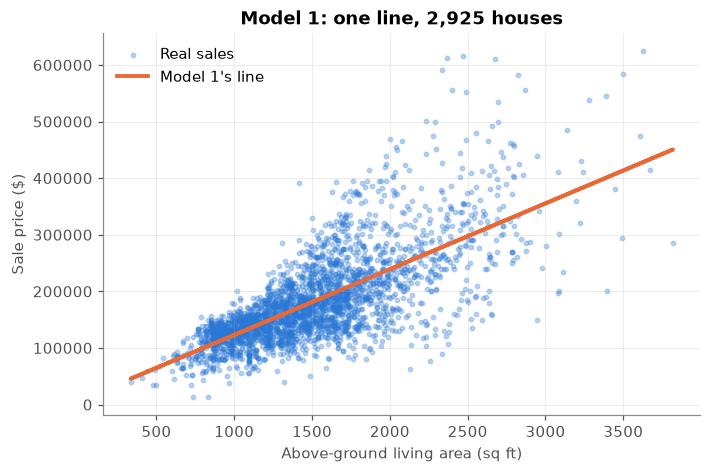

In [14]:
# Ask the trained model for predictions, then draw its line over the real dots.
pred_line = model_1.predict(X_simple)

plt.figure(figsize=(7, 4.5))
plt.scatter(houses["Gr Liv Area"], y, s=8, alpha=0.3, color=BLUE, label="Real sales")
plt.plot(houses["Gr Liv Area"], pred_line, color=ORANGE, linewidth=2.5, label="Model 1's line")
plt.xlabel("Above-ground living area (sq ft)"); plt.ylabel("Sale price ($)")
plt.title("Model 1: one line, 2,925 houses")
plt.legend(frameon=False)
plt.show()

**What happened.** `.predict(X)` runs the learned formula on every row and returns the
predicted prices. Plotting those against size draws the line.

**Look at it honestly.** The line follows the trend — it is clearly not nonsense. But
at 2,000 sq ft, real houses sold anywhere from \$100k to \$450k, and the line commits
to one number around \$240k. Size alone cannot explain that spread. A 2,000 sq ft house
in a good neighbourhood with a new kitchen is a different product from a 2,000 sq ft
house next to the railway.

So: how *wrong* is this line, in dollars? Time for the most important part of the notebook.

---
# Part 5 — Judging a model: MAE, MSE, RMSE and R²

### First, the rule that everything else depends on

We just scored the model on the same 2,925 houses it learned from. That is like giving
students the exam they already have the answer key to. The score is meaningless.

**Split the data.** Hide a random 20% of houses in a locked drawer. Train on the other
80%. Then test on the drawer. The model has never seen those houses, so its score there
is an honest estimate of how it will behave on a house that walks in tomorrow.

This is called a **train/test split**, and skipping it is the single most common and
most damaging mistake in applied machine learning.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y,
    test_size=0.2,        # 20% goes in the locked drawer
    random_state=42       # a fixed "seed" so the split is identical every run
)

print(f"Training set: {len(X_train):,} houses  (the model studies these)")
print(f"Test set:     {len(X_test):,} houses  (the model never sees these until scoring)")

Training set: 2,340 houses  (the model studies these)
Test set:     585 houses  (the model never sees these until scoring)


**What happened.** `train_test_split` shuffles the rows and cuts them in two,
returning four things in this exact order: training features, test features, training
target, test target. That order never changes, so memorise the line.

`random_state=42` fixes the random shuffle so you and I get the *same* split. Without
it, every run gives slightly different scores and you can't tell a real improvement
from luck. (42 is a joke from *The Hitchhiker's Guide to the Galaxy* that became the
field's default. Any number works.)

In [16]:
# Retrain on the training half only, then predict the locked-away test half.
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)

# Show the first five predictions against reality.
comparison = pd.DataFrame({
    "Actual": y_test.values[:5],
    "Predicted": y_pred[:5].round(0),
})
comparison["Error"] = comparison["Predicted"] - comparison["Actual"]
comparison

,Actual,Predicted,Error
0,143000,175784.0,32784.0
1,437154,319196.0,-117958.0
2,205950,199348.0,-6602.0
3,235000,152785.0,-82215.0
4,138000,226294.0,88294.0


**What happened.** We built a fresh model, trained it on the 2,340 training houses,
and asked it to price the 585 test houses. The table shows the first five: what the
house actually sold for, what the model guessed, and the gap.

Some guesses are close. Some are off by \$60,000 or more. We need one number that
summarises all 585 gaps. There are four standard ones.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE   {mae:>14,.0f}   average miss, in dollars")
print(f"MSE   {mse:>14,.0f}   average SQUARED miss, in dollars-squared")
print(f"RMSE  {rmse:>14,.0f}   square root of MSE, back in dollars")
print(f"R²    {r2:>14.3f}   share of price variation explained (0 to 1)")

MAE           39,604   average miss, in dollars
MSE    3,424,542,702   average SQUARED miss, in dollars-squared
RMSE          58,520   square root of MSE, back in dollars
R²             0.518   share of price variation explained (0 to 1)


**What happened — and what each number actually means.**

---

### MAE — Mean Absolute Error
Take every error, drop the minus signs, average them.

```
MAE  =  average of  | actual - predicted |
```

**Reads as:** *"On average this model is off by about \$39,000."* It is in dollars, so
you can say it to a client. Every error counts the same — being wrong by \$100k twice
is exactly as bad as being wrong by \$50k four times.

**Use it when** big misses aren't disproportionately costly, or when your data has
genuine outliers you don't want dominating the score.

---

### MSE — Mean Squared Error
Square every error before averaging.

```
MSE  =  average of  ( actual - predicted )²
```

**Reads as:** …nothing you can say out loud. The units are *dollars squared*, which
is not a thing. That number above is meaningless in isolation. MSE's job isn't to be
read — it's to be *minimised*. Squaring makes one \$200k catastrophe count sixteen
times as much as one \$50k slip, so a model trained to minimise MSE works hard to
avoid disasters. This is the quantity almost every regression algorithm optimises
internally, including all of Models 1–6.

---

### RMSE — Root Mean Squared Error
The square root of MSE, which drags the units back to dollars.

**Reads as:** *"Typical error around \$58,500."* This is the number to report when big
misses matter more than small ones. **RMSE is always ≥ MAE**, and the gap between them
tells you something: here \$58.5k against \$39.6k means a minority of houses are being missed
badly, pulling RMSE up. If MAE and RMSE were nearly equal, errors would be uniformly
small. That gap is free diagnostic information — always look at both.

---

### R² — R-squared, "the coefficient of determination"
The share of price variation the model explains.

- **R² = 1.0** — perfect, every prediction exact. (If you see this, you have a bug.)
- **R² = 0.0** — the model is no better than always guessing the average price.
- **R² < 0** — worse than guessing the average. Yes, this is possible, and you'll see it.

**Reads as:** *"Size alone explains about 50% of why Ames houses differ in price."*
The other 50% is neighbourhood, quality, age, and everything else we haven't shown it yet.

**The trap:** R² never decreases when you add features, even useless random ones. So
R² measured on *training* data always rewards a bigger model. R² on *test* data —
which is what we computed — is honest. Only ever trust the test one.

---

### Which one should you actually use?

| Metric | Units | Punishes big misses? | Say it to a client? |
|---|---|---|---|
| **MAE** | dollars | no, all errors equal | yes — clearest |
| **MSE** | dollars² | heavily | no — meaningless units |
| **RMSE** | dollars | heavily | yes — the standard report |
| **R²** | none (0–1) | — | yes — "explains X% of variation" |

In practice: **report MAE and R² to humans, watch RMSE while tuning, and let the
algorithm minimise MSE internally.** We'll track all four for every model from here on.

In [18]:
# A results table we'll add one row to after every model.
results = []

def score_model(name, y_true, y_hat, note="", key=""):
    """Score a model, print it, and remember it for the final comparison."""
    row = {
        "Model": name,
        "key": key,
        "MAE ($)": mean_absolute_error(y_true, y_hat),
        "RMSE ($)": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R²": r2_score(y_true, y_hat),
        "Note": note,
    }
    results.append(row)
    print(f"{name:<28} MAE ${row['MAE ($)']:>8,.0f}   RMSE ${row['RMSE ($)']:>8,.0f}   R² {row['R²']:.3f}")

score_model("1. Simple Linear (1 feature)", y_test, y_pred, "Size only", "01_simple_linear")

1. Simple Linear (1 feature) MAE $  39,604   RMSE $  58,520   R² 0.518


**What happened.** We wrote our own small function so we never have to repeat those
four metric calls. It computes the scores, prints one tidy line, and appends the
numbers to the `results` list for the leaderboard at the end. The text in triple
quotes is a *docstring* — a note to whoever reads the code later.

**Our baseline is set: off by \$39k on average, explaining 50% of price variation.**
Every model from here has to beat that.

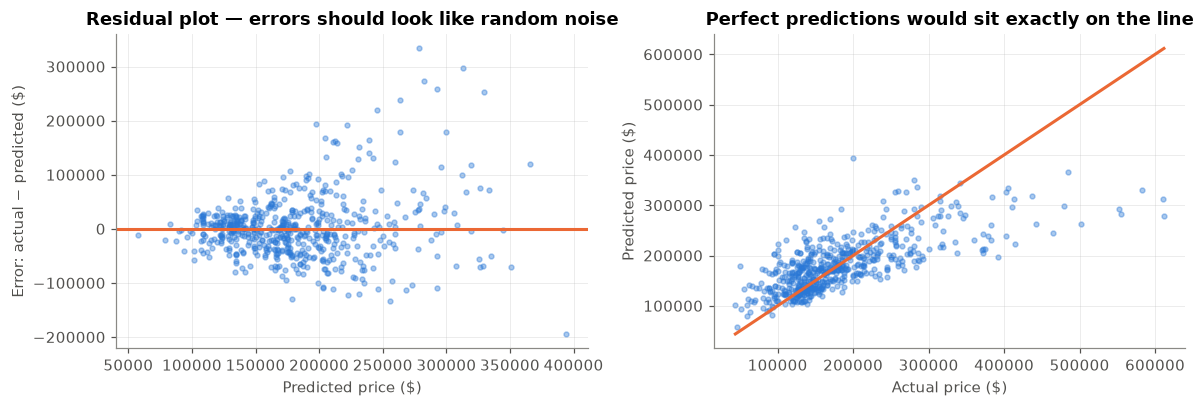

In [19]:
# One more diagnostic that no metric can replace: look at the errors.
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].scatter(y_pred, residuals, s=10, alpha=0.4, color=BLUE)
axes[0].axhline(0, color=ORANGE, linewidth=2)
axes[0].set_xlabel("Predicted price ($)"); axes[0].set_ylabel("Error: actual − predicted ($)")
axes[0].set_title("Residual plot — errors should look like random noise")

axes[1].scatter(y_test, y_pred, s=10, alpha=0.4, color=BLUE)
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color=ORANGE, linewidth=2)
axes[1].set_xlabel("Actual price ($)"); axes[1].set_ylabel("Predicted price ($)")
axes[1].set_title("Perfect predictions would sit exactly on the line")

plt.tight_layout(); plt.show()

**What happened.** `residuals = y_test - y_pred` is the leftover error on every test
house. Two ways of looking at the same thing:

**Left (residual plot).** If a model has squeezed out all the signal, its errors should
be a shapeless cloud centred on zero. Ours isn't shapeless: the spread *widens* as
predicted price rises, and there's a run of large positive errors on expensive houses.
That fan shape is the model systematically under-pricing good houses, because "good"
is a thing it cannot see. **A residual plot with a pattern in it is the model telling
you what feature you forgot.**

**Right (predicted vs actual).** Perfect predictions lie on the diagonal. Ours sit in a
fat cloud around it, drifting below the line at the top end — same story, confirmed.

The fix is obvious. Show the model more than one thing about each house.

---
# Part 6 — Model 2: Multiple Linear Regression

### The idea in one sentence
**Same straight-line thinking, but with one slope per feature instead of one slope total.**

```
price  =  b  +  m1 x size  +  m2 x quality  +  m3 x year  +  ...
```

Geometrically it's no longer a line on a page — with 20 features it's a flat surface in
20-dimensional space, which nobody can picture and nobody needs to. The mechanics are
identical: find the coefficients that minimise squared error.

But real data fights back before we get there. Two problems to solve first.

In [20]:
# Pick the features. These are the facts a competent estate agent would actually ask about.
numeric_features = [
    "Gr Liv Area",      # above-ground living area, sq ft
    "Total Bsmt SF",    # basement area, sq ft
    "1st Flr SF",       # first floor area, sq ft
    "Lot Area",         # plot size, sq ft
    "Overall Qual",     # 1-10 material & finish rating
    "Overall Cond",     # 1-10 condition rating
    "Year Built",
    "Year Remod/Add",   # year of last remodel
    "Garage Cars",      # capacity in cars
    "Garage Area",
    "Full Bath",
    "Half Bath",
    "TotRms AbvGrd",    # total rooms above ground
    "Fireplaces",
    "Mas Vnr Area",     # masonry veneer area, sq ft
    "Wood Deck SF",
    "Open Porch SF",
]

categorical_features = [
    "Neighborhood",     # 28 districts of Ames
    "House Style",      # 1-storey, 2-storey, split-level...
    "Bldg Type",        # detached, townhouse, duplex...
    "Exter Qual",       # exterior material quality
    "Kitchen Qual",
    "Bsmt Qual",
    "Heating QC",
    "Central Air",      # Y / N
    "Foundation",
    "Garage Type",
]

all_features = numeric_features + categorical_features    # + joins two lists
print(f"{len(numeric_features)} numeric + {len(categorical_features)} categorical "
      f"= {len(all_features)} features")

17 numeric + 10 categorical = 27 features


**What happened.** We wrote two plain Python lists of column names. Nothing clever —
this is a human decision about what matters, and it is usually the highest-leverage
decision in the whole project. We deliberately left out things like `Order` and `PID`
(row number and parcel ID), which are just labels and carry no information about value.

In [21]:
# PROBLEM 1: missing values. Linear regression crashes on empty cells.
X = houses[all_features]
missing = X.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Garage Type      157
Bsmt Qual         80
Mas Vnr Area      23
Total Bsmt SF      1
Garage Cars        1
Garage Area        1
dtype: int64


**What happened.** `.isna()` marks every empty cell as True, `.sum()` counts them per
column. Real data has holes — 490 houses have no recorded lot frontage, 157 have no
garage type (because they have no garage).

We can't delete those rows; we'd lose a fifth of the dataset. Instead we **impute** —
fill each hole with a sensible stand-in. For numbers, the *median* of that column. For
categories, the literal word `"Missing"`, treated as its own category, because "no
garage" is itself informative.

**PROBLEM 2: words.** `Neighborhood` contains `"NAmes"`, `"CollgCr"`, `"OldTown"`.
Mathematics cannot multiply a coefficient by `"OldTown"`.

The wrong fix is to number them 1, 2, 3 — that tells the model OldTown is three times
NAmes, which is nonsense. The right fix is **one-hot encoding**: turn one column of 28
neighbourhoods into 28 yes/no columns.

| Neighborhood | → | is_NAmes | is_CollgCr | is_OldTown |
|---|---|---|---|---|
| NAmes | | 1 | 0 | 0 |
| OldTown | | 0 | 0 | 1 |

Now each neighbourhood gets its own independent coefficient — its own dollar premium
or discount — with no fake ordering implied.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Recipe for the number columns: fill holes with the median, then rescale.
numeric_pipe = Pipeline([
    ("fill",  SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Recipe for the word columns: fill holes with "Missing", then one-hot encode.
categorical_pipe = Pipeline([
    ("fill",   SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Apply each recipe to the right columns.
preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

print("Preprocessor built. It will be reused, unchanged, by every model from here on.")

Preprocessor built. It will be reused, unchanged, by every model from here on.


**What happened — this is the most important piece of engineering in the notebook.**

- **`SimpleImputer`** fills the holes. `strategy="median"` for numbers,
  `strategy="constant", fill_value="Missing"` for words.
- **`StandardScaler`** rewrites each number as "how many standard deviations from this
  column's average". Lot Area runs to 200,000 while Full Bath runs to 4; without
  rescaling, models that measure distance or penalise large coefficients would treat
  Lot Area as thousands of times more important purely because of its units. Plain
  linear regression doesn't care, but Ridge, Lasso and SVR care enormously — so we
  scale from the start and keep every model comparable.
- **`OneHotEncoder`** does the yes/no expansion. `handle_unknown="ignore"` means if a
  neighbourhood appears in the test set that wasn't in training, it quietly becomes all
  zeros instead of crashing.
- **`Pipeline`** chains steps so they always run in the same order.
- **`ColumnTransformer`** routes numeric columns down one pipe and categorical down
  the other, then glues the results back together.

**Why this matters far more than it looks.** A pipeline learns its settings (the
medians, the category list, the scaling factors) *from the training data only*, and
then applies those exact settings to the test data. If you instead computed the median
across the whole dataset before splitting, information from the test set would leak
into training and your scores would be quietly, invisibly inflated. That is called
**data leakage**, it is the most expensive bug in machine learning, and a Pipeline
makes it structurally impossible.

In [23]:
# Re-split, this time with all 27 features.
X = houses[all_features]
y = houses["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Glue the preprocessor to the model so they train and predict as one object.
model_2 = Pipeline([
    ("prep",  preprocessor),
    ("model", LinearRegression()),
])

model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

score_model("2. Multiple Linear (27 feat)", y_test, y_pred_2, "All features", "02_multiple_linear")

2. Multiple Linear (27 feat) MAE $  15,392   RMSE $  23,701   R² 0.921


**What happened.** `model_2` is a two-step pipeline: preprocess, then fit a line.
Calling `.fit()` on it runs both steps in order. Calling `.predict()` applies the
*same learned* preprocessing to the test set and then the model.

**The result.** MAE dropped from about \$39,600 to about \$15,400 — the average miss
fell by more than half. R² went from 0.52 to 0.92: we now explain 92% of why Ames
houses differ in price, up from 52%.

That is the largest single improvement in this entire notebook, and it came from
**giving the model better information**, not from a cleverer algorithm. Remember that
when you're tempted to reach for a fancier model: more relevant features beat a
smarter algorithm almost every time.

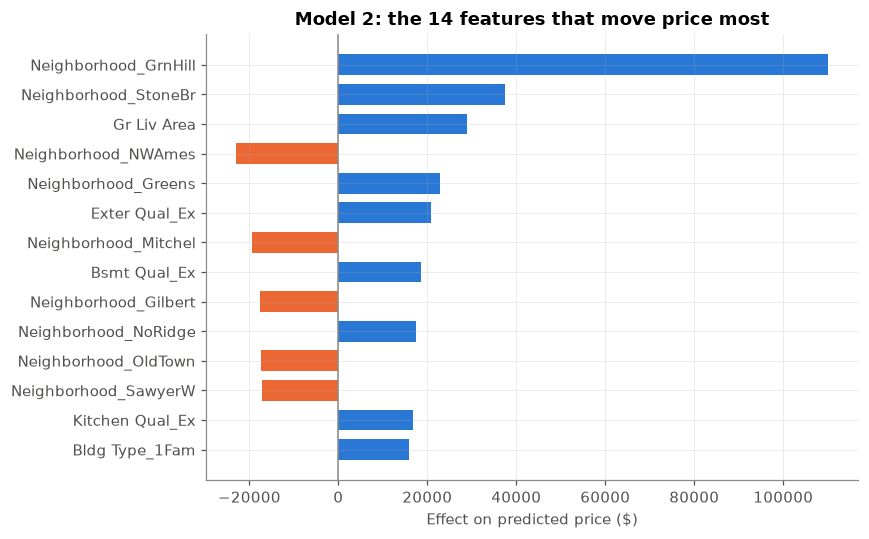

In [24]:
# What did it learn? Pull out the coefficients and read the biggest ones.
feature_names = model_2.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(model_2.named_steps["model"].coef_, index=feature_names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:14][::-1]

plt.figure(figsize=(8, 5))
colors = [ORANGE if v < 0 else BLUE for v in top.values]
plt.barh(range(len(top)), top.values, color=colors, height=0.7)
plt.yticks(range(len(top)), [n.split("__")[-1] for n in top.index])
plt.axvline(0, color="#8a8985", linewidth=1)
plt.xlabel("Effect on predicted price ($)")
plt.title("Model 2: the 14 features that move price most")
plt.tight_layout(); plt.show()

**What happened.** `.get_feature_names_out()` asks the preprocessor what its output
columns are called after one-hot expansion. We paired those names with the learned
coefficients, sorted by absolute size (`.abs()`, so big negatives count too), took the
top 14, and drew a horizontal bar chart. Blue pushes price up, orange pushes it down.

**Careful how you read this.** Because we scaled the numeric features, a numeric
coefficient means *"dollars added per one standard deviation of this feature"*, not
per unit. The one-hot columns are still 0/1, so those read directly as a dollar
premium or discount for belonging to that category. Mixing the two on one axis is a
little loose — it's here to show you the *shape* of what the model learned, and the
shape is sensible: quality and size dominate, and a handful of neighbourhoods carry
real money.

**The honest warning.** When features are correlated — and `Garage Cars` and
`Garage Area` obviously are — linear regression can split credit between them
arbitrarily, sometimes flipping a sign. That instability is called
**multicollinearity**, and it's exactly the disease Ridge regression was invented to
cure. Hold that thought.

---
# Part 7 — Model 3: Polynomial Regression

### The idea in one sentence
**Keep linear regression, but feed it squared and multiplied versions of the features
so it can fit curves.**

Not every relationship is a straight line. Going from quality 3 to 4 might add \$15k;
going from 9 to 10 might add \$80k. That's a curve, and no straight line can capture it.

The trick is beautifully lazy: don't invent a curve-fitting algorithm. Just invent new
columns — size², quality², size×quality — and hand them to the same old linear
regression. A straight line through *squared* inputs is a curve in the original space.

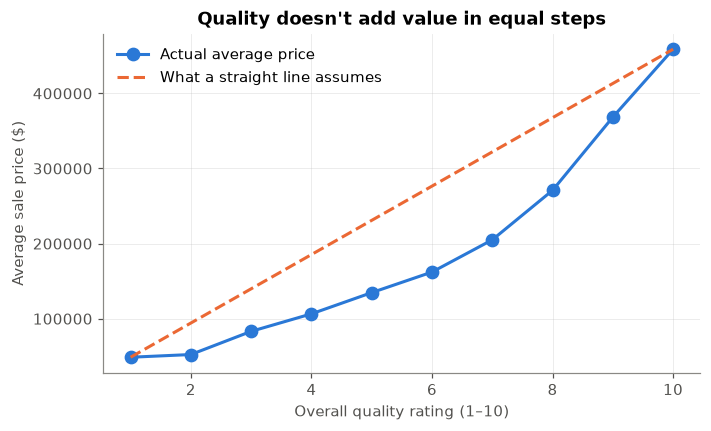

In [25]:
# First, is there actually a curve? Look at average price per quality rating.
by_qual = houses.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(7, 4))
plt.plot(by_qual.index, by_qual.values, marker="o", markersize=8,
         color=BLUE, linewidth=2, label="Actual average price")
plt.plot([by_qual.index.min(), by_qual.index.max()],
         [by_qual.values.min(), by_qual.values.max()],
         color=ORANGE, linewidth=2, linestyle="--", label="What a straight line assumes")
plt.xlabel("Overall quality rating (1–10)"); plt.ylabel("Average sale price ($)")
plt.title("Quality doesn't add value in equal steps")
plt.legend(frameon=False)
plt.show()

**What happened.** `.groupby("Overall Qual")["SalePrice"].mean()` splits houses into
ten quality groups and averages the price in each. The blue line is reality; the dashed
orange line is what a straight-line model is forced to assume.

Reality curves upward — the jump from 9 to 10 is worth far more than the jump from 3
to 4. A straight line splits the difference and is wrong at both ends. **This is the
gap polynomial features close.**

In [26]:
from sklearn.preprocessing import PolynomialFeatures

# Same preprocessor, but the numeric branch now also generates squares and products.
poly_numeric_pipe = Pipeline([
    ("fill",  SimpleImputer(strategy="median")),
    ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
])

poly_preprocessor = ColumnTransformer([
    ("num", poly_numeric_pipe,  numeric_features),
    ("cat", categorical_pipe,   categorical_features),
])

model_3 = Pipeline([("prep", poly_preprocessor), ("model", LinearRegression())])
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

n_before = len(numeric_features)
n_after = model_3.named_steps["prep"].transform(X_train.head(1)).shape[1]
print(f"Columns going in:  {len(all_features)}")
print(f"Columns after expansion: {n_after}\n")

score_model("3. Polynomial (degree 2)", y_test, y_pred_3, "Squares & interactions", "03_polynomial")

Columns going in:  27
Columns after expansion: 245

3. Polynomial (degree 2)     MAE $  14,422   RMSE $  24,002   R² 0.919


**What happened.** `PolynomialFeatures(degree=2)` takes the 17 numeric columns and
generates every square and every pairwise product: `Gr Liv Area²`,
`Gr Liv Area × Overall Qual`, and so on. 17 columns became 170. Add the one-hot
categorical columns and the model is now fitting a coefficient to several hundred
features. `include_bias=False` skips a redundant column of 1s that LinearRegression
already handles.

Those product terms are the real prize. `Gr Liv Area × Overall Qual` lets the model
express *"square footage is worth more in a high-quality house"* — an **interaction**
that no amount of separate coefficients can capture.

**Read the score carefully — it's a split decision.** MAE improved (the typical house
is priced better), but RMSE got slightly *worse* (a few houses are now missed badly).
That is the MAE-versus-RMSE gap from Part 5 doing its job: the extra flexibility helps
on ordinary houses and hurts on unusual ones. A single number would have hidden this.

Now watch what happens when we get greedy.

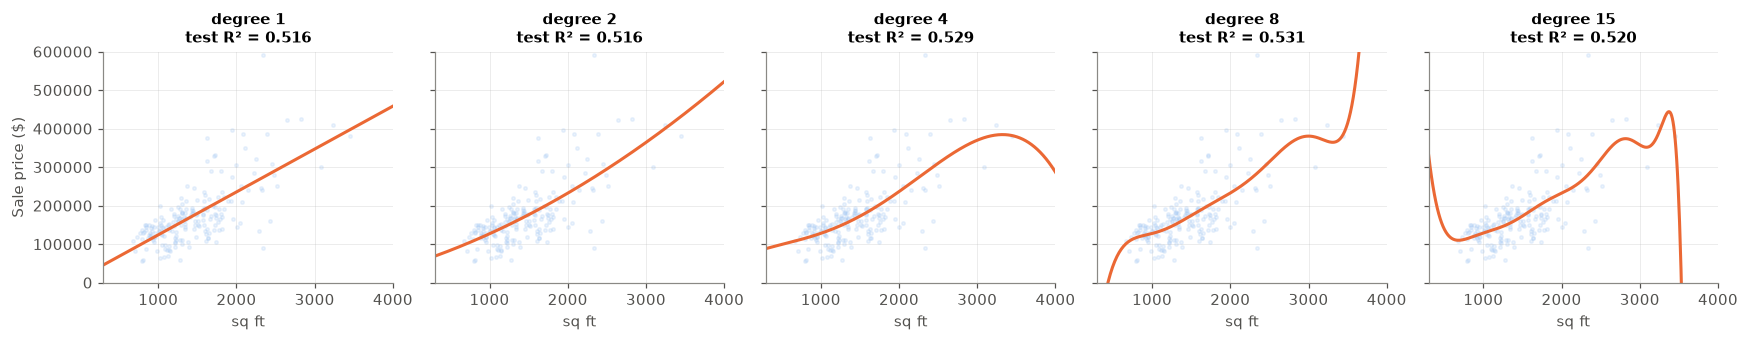

In [27]:
# The overfitting demo. One feature, five increasingly flexible curves.
from sklearn.preprocessing import PolynomialFeatures

x_one = houses[["Gr Liv Area"]]
xtr_full, xte, ytr_full, yte = train_test_split(x_one, y, test_size=0.2, random_state=42)

# Deliberately train on only 200 houses. Overfitting is a data-scarcity disease:
# with 2,000 examples even a silly model behaves; with 200 it starts to run riot.
xtr = xtr_full.sample(200, random_state=7)
ytr = ytr_full.loc[xtr.index]

grid = pd.DataFrame({"Gr Liv Area": np.linspace(300, 4000, 400)})
degrees = [1, 2, 4, 8, 15]
train_scores, test_scores = [], []

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for ax, d in zip(axes, degrees):
    m = Pipeline([("poly", PolynomialFeatures(degree=d, include_bias=False)),
                  ("scale", StandardScaler()),
                  ("lin", LinearRegression())])
    m.fit(xtr, ytr)
    train_scores.append(r2_score(ytr, m.predict(xtr)))
    test_scores.append(r2_score(yte, m.predict(xte)))
    ax.scatter(xtr["Gr Liv Area"], ytr, s=5, alpha=0.2, color="#9ec5f4")
    ax.plot(grid["Gr Liv Area"], m.predict(grid), color=ORANGE, linewidth=2)
    ax.set_ylim(0, 600000); ax.set_xlim(300, 4000)
    ax.set_title(f"degree {d}\ntest R² = {test_scores[-1]:.3f}", fontsize=10)
    ax.set_xlabel("sq ft")
axes[0].set_ylabel("Sale price ($)")
plt.tight_layout(); plt.show()

**What happened.** We took **200** training houses — overfitting is a data-scarcity
disease, and with 2,000 examples even a silly model behaves itself — and fit the same
one-feature model five times with increasing polynomial degree.

- **Degree 1** — a straight line. A little too rigid.
- **Degree 2** — a gentle bend. About the same.
- **Degree 4** — the best of the five on unseen houses. This is the sweet spot.
- **Degree 8** — the curve starts writhing, swinging at the edges where there are few
  houses, chasing individual dots that are just noise.
- **Degree 15** — completely off the rails. It shoots past the top of the chart.

That last behaviour is **overfitting**: the model stopped learning the *pattern* and
started memorising the *sample*. Let's measure it rather than eyeball it.

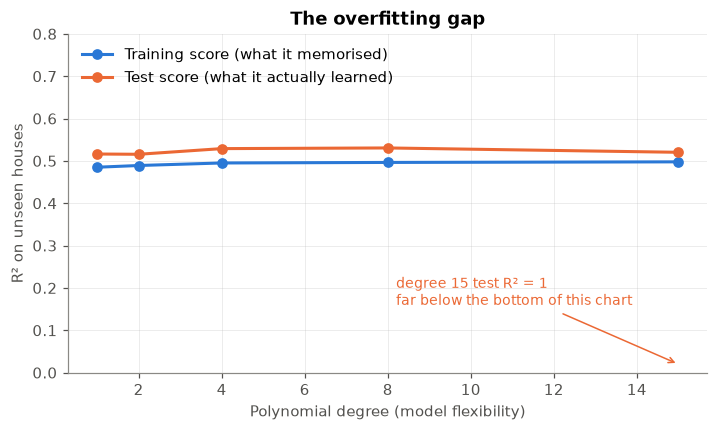

degree  1:  train R²  0.485   test R²          0.516
degree  2:  train R²  0.489   test R²          0.516
degree  4:  train R²  0.495   test R²          0.529
degree  8:  train R²  0.496   test R²          0.531
degree 15:  train R²  0.498   test R²          0.520


In [28]:
plt.figure(figsize=(7.5, 4))
plt.plot(degrees, train_scores, marker="o", color=BLUE, linewidth=2,
         label="Training score (what it memorised)")
plt.plot(degrees, test_scores, marker="o", color=ORANGE, linewidth=2,
         label="Test score (what it actually learned)")
plt.ylim(0, 0.8)                       # degree 15's test score is far below zero
plt.annotate(f"degree 15 test R² = {test_scores[-1]:,.0f}\nfar below the bottom of this chart",
             xy=(15, 0.02), xytext=(8.2, 0.16), color=ORANGE, fontsize=9,
             arrowprops=dict(arrowstyle="->", color=ORANGE))
plt.xlabel("Polynomial degree (model flexibility)"); plt.ylabel("R² on unseen houses")
plt.title("The overfitting gap")
plt.legend(frameon=False, loc="upper left")
plt.show()

for d, tr, te in zip(degrees, train_scores, test_scores):
    print(f"degree {d:>2}:  train R² {tr:>6.3f}   test R² {te:>14,.3f}")

**What happened — and this is the central lesson of machine learning.**

The blue line (training score) keeps climbing as the model gets more flexible. Of
course it does: a wigglier curve can always pass closer to the points it was shown.

The orange line (test score) climbs to a peak at **degree 4**, then falls, then
collapses entirely. Past a certain flexibility the model is fitting noise, and noise
doesn't repeat on new houses.

**That degree-15 test R² is not a typo.** R² of 0 means "no better than always guessing
the average price". A large *negative* R² means the model is catastrophically worse
than that — its curve rockets off to absurd values at the edges of the data. The model
that looked *best* on training data is the one that would lose you the most money.

The distance between the two lines is the **overfitting gap**. It is the difference
between a student who understands the subject and a student who memorised the practice
exam. Both ace the practice exam. Only one passes the real one.

> **This is why you always hold out a test set.** Judged on training data, degree 20
> looks like the best model here. It is the worst.

So we need flexible models that can't run away with themselves. That is exactly what
the next three models do.

---
# Part 8 — Models 4, 5 & 6: Ridge, Lasso and Elastic Net

### The idea in one sentence
**Add a fine to the model's scorecard for using large coefficients, so it only takes
complexity it can pay for.**

Overfitting shows up in the coefficients. When a model contorts itself to hit every
point, its coefficients balloon — one feature gets +900,000 and its neighbour gets
−880,000, and they cancel out on the training data. It's a house of cards.

**Regularisation** changes what the model is minimising. Instead of just:

```
minimise:   sum of ( error )²
```

it minimises:

```
minimise:   sum of ( error )²   +   alpha x ( total size of the coefficients )
```

Now a coefficient has to *earn* its size. If adding it reduces error by less than the
fine it costs, the model shrinks it back. The strength of the fine is **alpha (α)**:

- **α = 0** → no fine at all → ordinary linear regression.
- **α small** → gentle shrinking, still flexible.
- **α huge** → everything crushed to zero → the model predicts the average, always.

The three models differ only in **how they measure "size of coefficients"**.

### Ridge — the L2 penalty
Fine = the sum of **squared** coefficients. Squaring means huge coefficients are
punished disproportionately, so Ridge shrinks everything smoothly toward zero but
never quite *to* zero. Every feature survives, just quieter.

**Best when** you have many correlated features (Garage Cars and Garage Area) and want
the model to share credit between them sensibly instead of picking arbitrarily.

### Lasso — the L1 penalty
Fine = the sum of **absolute** coefficients. Because the penalty doesn't ease off as a
coefficient approaches zero, Lasso pushes weak coefficients *exactly* to zero and
leaves them there. Those features are effectively deleted.

**Best when** you suspect most of your features are useless and you want the model to
tell you which ones. Lasso does automatic feature selection for free.
(The name is an acronym: Least Absolute Shrinkage and Selection Operator.)

### Elastic Net — both
Fine = a blend of the two, controlled by `l1_ratio` (0 = pure Ridge, 1 = pure Lasso).
Gets Lasso's ability to delete features without Lasso's habit of arbitrarily keeping
one member of a correlated group and dropping the rest.

**Best when** you have many features, some correlated, some useless — which is most
real datasets.

### But how do we choose alpha?

Not by trying values on the test set — that would turn the test set into training data
by the back door, and we'd be lying to ourselves again.

Instead: **cross-validation**. Split the *training* data into 5 chunks. Train on 4,
validate on the 5th. Rotate so each chunk gets a turn. Average the 5 scores. Do that
for every candidate alpha and keep the winner. The test set stays locked in the drawer
the whole time.

Scikit-learn ships `RidgeCV`, `LassoCV` and `ElasticNetCV`, which do the whole search
in one call.

In [29]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-2, 4, 60)     # 60 candidate values from 0.01 to 10,000

# Ridge, on the polynomial feature set — that's where overfitting was worst.
model_4 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=5)),
])
model_4.fit(X_train, y_train)
y_pred_4 = model_4.predict(X_test)

print(f"Ridge picked alpha = {model_4.named_steps['model'].alpha_:,.2f}\n")
score_model("4. Ridge (L2)", y_test, y_pred_4, "Polynomial + shrinkage", "04_ridge")

Ridge picked alpha = 45.82

4. Ridge (L2)                MAE $  13,829   RMSE $  22,230   R² 0.930


**What happened.** `np.logspace(-2, 4, 60)` builds 60 alpha values spread evenly on a
*logarithmic* scale — 0.01, 0.014, 0.02, … up to 10,000. Log spacing is right here
because what matters is the order of magnitude, not the absolute step.

`RidgeCV(alphas=..., cv=5)` fits the model once per alpha per fold, keeps the alpha
with the best average validation score, and refits on the full training set. The
chosen value lands in `.alpha_`.

Compare this to Model 3: same features, same algorithm underneath, but with the fine
applied the test score improves. The wild polynomial terms have been reined in.

In [30]:
# Lasso is solved by iterative approximation, and on 245 correlated polynomial features
# it keeps nudging coefficients long after the answer has stopped meaningfully changing.
# It prints a warning every time. We silence that ONE warning to keep the output readable.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_5 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)),
])
model_5.fit(X_train, y_train)
y_pred_5 = model_5.predict(X_test)

lasso_coefs = model_5.named_steps["model"].coef_
n_total = len(lasso_coefs)
n_zero = int((lasso_coefs == 0).sum())

print(f"Lasso picked alpha = {model_5.named_steps['model'].alpha_:,.2f}")
print(f"Features available: {n_total}")
print(f"Features deleted (coefficient set to exactly 0): {n_zero}  ({n_zero/n_total:.0%})")
print(f"Features kept: {n_total - n_zero}\n")

score_model("5. Lasso (L1)", y_test, y_pred_5, f"Kept {n_total-n_zero}/{n_total} features", "05_lasso")

Lasso picked alpha = 116.90
Features available: 245
Features deleted (coefficient set to exactly 0): 162  (66%)
Features kept: 83

5. Lasso (L1)                MAE $  13,905   RMSE $  21,661   R² 0.934


**What happened.** Same pipeline, different penalty. `max_iter=20000` gives the solver
20,000 attempts to settle.

**About that warning filter.** Never silence a warning you haven't read. This one says
the solver hit its iteration limit before its internal convergence test passed — but
the coefficients have long since stopped moving in any way that changes a prediction,
and it fires once per alpha per fold, which would bury the notebook in 300 identical
red boxes. Reading it, understanding it, then silencing that specific class is fine.
Blanket-silencing all warnings is how people ship broken models.

**Look at the deletion count.** Lasso threw away a large share of the several hundred
polynomial features by setting their coefficients to exactly zero — and the score
held up or improved. It read our feature list and told us most of it was noise.

That is genuinely useful beyond the score: if you were building this for production,
Lasso just told you which columns you can stop collecting.

In [31]:
# Elastic Net — searches l1_ratio as well as alpha.
model_6 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                           alphas=alphas, cv=5, max_iter=20000, random_state=42)),
])
model_6.fit(X_train, y_train)
y_pred_6 = model_6.predict(X_test)

en = model_6.named_steps["model"]
print(f"Elastic Net picked alpha = {en.alpha_:,.2f}, l1_ratio = {en.l1_ratio_}")
print(f"   (l1_ratio 0 = pure Ridge, 1 = pure Lasso)\n")
score_model("6. Elastic Net (L1+L2)", y_test, y_pred_6, f"l1_ratio={en.l1_ratio_}", "06_elastic_net")

Elastic Net picked alpha = 116.90, l1_ratio = 1.0
   (l1_ratio 0 = pure Ridge, 1 = pure Lasso)

6. Elastic Net (L1+L2)       MAE $  13,905   RMSE $  21,661   R² 0.934


**What happened.** `ElasticNetCV` runs the same cross-validated search across a
2-D grid: every alpha × every l1_ratio. The winning `l1_ratio_` tells you which
penalty the data preferred — closer to 1 means it wanted features deleted, closer to 0
means it wanted them shrunk but kept.

**It came back at l1_ratio = 1.0 — pure Lasso — so Models 5 and 6 are the identical
model with identical scores.** That is not a bug and not a wasted cell. It is the
search honestly reporting that mixing in a Ridge penalty had nothing to offer on this
data. A tuning result that says "your simpler option was already right" is a real
finding, and worth more than a hyperparameter you tuned by vibes.

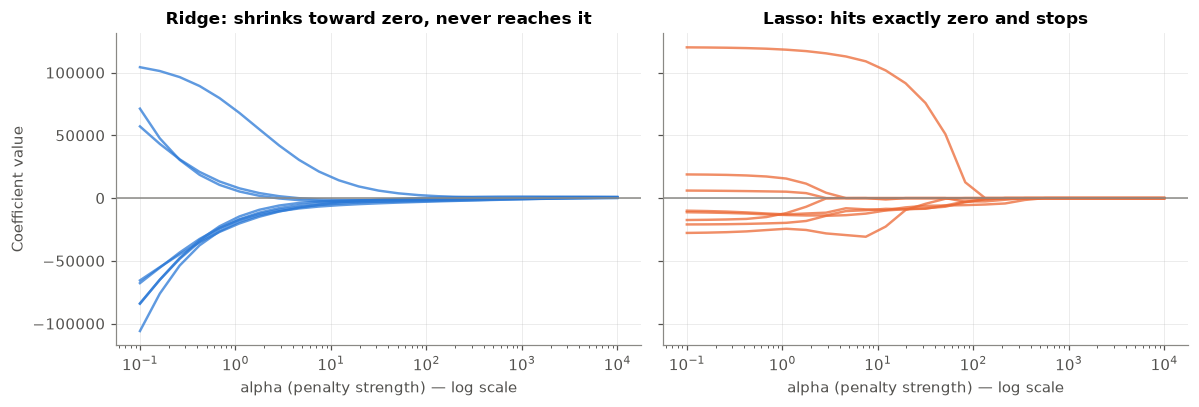

In [32]:
# See the shrinkage happen. Same feature, ten alphas, three penalties.
from sklearn.linear_model import Ridge, Lasso

test_alphas = np.logspace(-1, 4, 25)
Xtr_p = poly_preprocessor.fit_transform(X_train)
ridge_paths, lasso_paths = [], []
for a in test_alphas:
    ridge_paths.append(Ridge(alpha=a).fit(Xtr_p, y_train).coef_)
    lasso_paths.append(Lasso(alpha=a, max_iter=5000).fit(Xtr_p, y_train).coef_)
ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

pick = np.argsort(np.abs(ridge_paths[0]))[-8:]      # 8 initially-loudest features

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for i in pick:
    axes[0].plot(test_alphas, ridge_paths[:, i], color=BLUE, alpha=0.75, linewidth=1.6)
    axes[1].plot(test_alphas, lasso_paths[:, i], color=ORANGE, alpha=0.75, linewidth=1.6)
for ax, t in zip(axes, ["Ridge: shrinks toward zero, never reaches it",
                        "Lasso: hits exactly zero and stops"]):
    ax.set_xscale("log"); ax.axhline(0, color="#8a8985", linewidth=1)
    ax.set_xlabel("alpha (penalty strength) — log scale"); ax.set_title(t, fontsize=11)
axes[0].set_ylabel("Coefficient value")
plt.tight_layout(); plt.show()

**What happened.** We fit Ridge and Lasso 25 times each at increasing alpha and traced
what happened to eight coefficients. This picture *is* the difference between the two:

- **Left (Ridge):** every line glides toward zero as the fine rises, but they all stay
  alive, getting quieter together.
- **Right (Lasso):** lines hit zero one by one and flatline. Once a feature is out,
  it's out.

`np.argsort(np.abs(...))[-8:]` just picked the eight coefficients that started largest,
so the chart shows the interesting ones rather than 350 flat lines.

---
# Part 9 — Model 7: Support Vector Regression (SVR)

### The idea in one sentence
**Don't fit a line through the points — fit a *tube* around them, and only care about
the points that fall outside it.**

Every model so far punishes every error, however tiny. SVR takes a different view:
define a margin of tolerance, **epsilon (ε)**. If a prediction lands within ε of the
true price, the error counts as **zero**. Only points outside the tube generate any
penalty at all, and those points are the **support vectors** — literally the only
houses that shape the final model.

Two consequences:

1. **It ignores noise by design.** Small wobbles inside the tube can't drag the model
   around, which makes SVR unusually robust to outliers.
2. **It can bend, via the kernel trick.** With `kernel="rbf"`, SVR measures similarity
   between houses rather than fitting an equation to features — mathematically
   equivalent to fitting a straight tube in an infinite-dimensional space, without ever
   computing that space. This is one of the genuinely elegant ideas in machine learning.

Two knobs: **C** (how expensive it is to be outside the tube — high C means fit hard,
low C means stay simple) and **epsilon** (how wide the tube is).

In [33]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

# SVR needs the TARGET scaled too, not just the features. See the note below.
svr_inner = SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")

model_7 = Pipeline([
    ("prep",  preprocessor),
    ("model", TransformedTargetRegressor(regressor=svr_inner, transformer=StandardScaler())),
])
model_7.fit(X_train, y_train)
y_pred_7 = model_7.predict(X_test)

score_model("7. SVR (RBF kernel)", y_test, y_pred_7, "C=10, epsilon=0.1", "07_svr")

7. SVR (RBF kernel)          MAE $  15,396   RMSE $  22,674   R² 0.928


**What happened — and the trap that catches everybody.**

SVR's `epsilon=0.1` means "errors under 0.1 are free". House prices are in the
hundreds of thousands. A tolerance of ten cents is not a tolerance; every single house
lands outside the tube, and SVR grinds to a useless result — you'd get an R² near
zero and conclude SVR is rubbish.

**`TransformedTargetRegressor` is the fix.** It scales `y` down to roughly −3…+3 before
training (so epsilon 0.1 becomes a sensible margin), then automatically un-scales the
predictions back into dollars afterwards. You still read the score in dollars; SVR
gets to work in units that make sense to it.

**This is the general lesson, not an SVR quirk:** any algorithm built around distances
or margins — SVR, k-nearest neighbours, neural networks — needs its inputs *and often
its output* on a comparable scale. The tree models coming next are the exception:
they only ever ask "is this value above or below a threshold", which no amount of
rescaling changes.

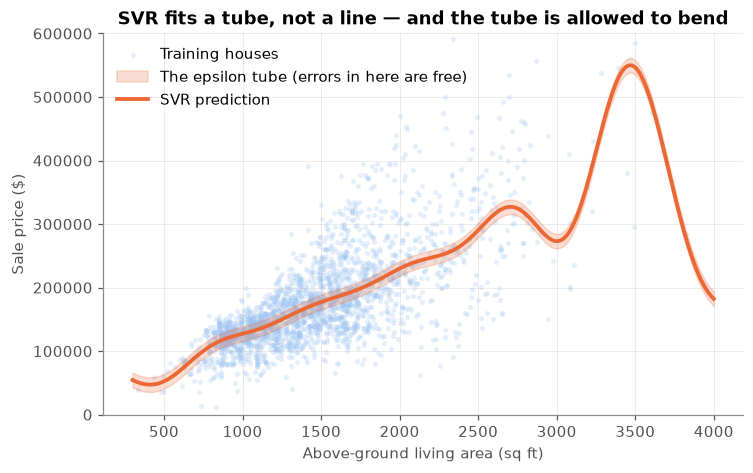

In [34]:
# What the tube actually looks like, on one feature so it's visible.
svr_demo = Pipeline([("scale", StandardScaler()),
                     ("m", TransformedTargetRegressor(regressor=SVR(kernel="rbf", C=50, epsilon=0.15),
                                                      transformer=StandardScaler()))])
svr_demo.fit(xtr_full, ytr_full)   # the FULL one-feature training set, not the 200-house sample
gx = pd.DataFrame({"Gr Liv Area": np.linspace(300, 4000, 300)})
gy = svr_demo.predict(gx)
band = 0.15 * ytr_full.std()

plt.figure(figsize=(7.5, 4.5))
plt.scatter(xtr_full["Gr Liv Area"], ytr_full, s=6, alpha=0.2, color="#9ec5f4", label="Training houses")
plt.fill_between(gx["Gr Liv Area"], gy - band, gy + band, color=ORANGE, alpha=0.22,
                 label="The epsilon tube (errors in here are free)")
plt.plot(gx["Gr Liv Area"], gy, color=ORANGE, linewidth=2.5, label="SVR prediction")
plt.ylim(0, 600000)
plt.xlabel("Above-ground living area (sq ft)"); plt.ylabel("Sale price ($)")
plt.title("SVR fits a tube, not a line — and the tube is allowed to bend")
plt.legend(frameon=False, loc="upper left")
plt.show()

**What happened.** A one-feature SVR so the geometry is visible. The shaded band is the
epsilon tube; the solid line is the prediction. Notice the line is *curved* — that's
the RBF kernel at work, with no polynomial features anywhere in sight.

**The honest trade-off.** SVR is slow: training time grows roughly with the square of
the number of rows, so 3,000 houses is fine and 3,000,000 is not. And it is a black
box — there is no coefficient to read, no "each square foot is worth \$111". You trade
interpretability for flexibility. Whether that's a good trade depends entirely on
whether anyone has to explain the model to a regulator.

---
# Part 10 — Model 8: Decision Tree

### The idea in one sentence
**Forget equations. Ask a series of yes/no questions until you've narrowed the house
down to a small group, then predict that group's average price.**

> Is quality above 7? → yes.
> Is it bigger than 1,800 sq ft? → yes.
> Was it built after 1990? → no.
> **Predict \$243,000** (the average of the 41 training houses that answered the same way).

The algorithm builds the tree greedily. At every step it tries every feature and every
possible cut-off, and picks the split that most reduces the variation in price inside
the two resulting groups. Then it repeats on each group. It stops when a group is small
enough or pure enough.

**What makes trees different from everything above:**

- They don't need scaling. "Is size > 1,800?" gives the same answer in any units.
- They handle non-linearity for free — no polynomial features needed.
- They find interactions automatically: once you've split on quality, the size cut-off
  inside the high-quality branch can differ from the low-quality one. That *is* an
  interaction, discovered rather than specified.
- You can show one to a non-technical person and they will follow it.

In [35]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# First: what happens with NO limit on depth?
unlimited = Pipeline([("prep", preprocessor),
                      ("model", DecisionTreeRegressor(random_state=42))])
unlimited.fit(X_train, y_train)

print(f"Tree depth: {unlimited.named_steps['model'].get_depth()} levels")
print(f"Leaf groups: {unlimited.named_steps['model'].get_n_leaves():,}")
print(f"Training R²: {r2_score(y_train, unlimited.predict(X_train)):.4f}   <-- looks perfect")
print(f"Test R²:     {r2_score(y_test,  unlimited.predict(X_test)):.4f}   <-- reality")

Tree depth: 25 levels
Leaf groups: 2,248
Training R²: 1.0000   <-- looks perfect
Test R²:     0.8232   <-- reality


**What happened.** With no limit, the tree kept splitting until nearly every training
house sat alone in its own leaf. Training R² is essentially 1.000 — the tree has
*memorised the training set perfectly*. Test R² is far lower.

This is overfitting in its purest, most visible form, and it's the same lesson as the
degree-20 polynomial, arrived at from a completely different direction. Any model
flexible enough to memorise, will.

The cure is **pruning**: limit how deep the tree can grow and how small a leaf can get.

In [36]:
# Search for a sensible depth using cross-validation on the TRAINING set only.
from sklearn.model_selection import GridSearchCV

tree_search = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(random_state=42))]),
    param_grid={
        "model__max_depth":         [4, 6, 8, 10, 12, None],
        "model__min_samples_leaf":  [1, 5, 10, 20],
    },
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
tree_search.fit(X_train, y_train)

print("Best settings found:", tree_search.best_params_)
model_8 = tree_search.best_estimator_
y_pred_8 = model_8.predict(X_test)

score_model("8. Decision Tree (pruned)", y_test, y_pred_8,
            f"depth={tree_search.best_params_['model__max_depth']}", "08_decision_tree")

Best settings found: {'model__max_depth': 10, 'model__min_samples_leaf': 20}
8. Decision Tree (pruned)    MAE $  19,285   RMSE $  28,036   R² 0.889


**What happened.** `GridSearchCV` tries every combination in `param_grid`
(6 depths × 4 leaf sizes = 24 combinations), scores each with 5-fold cross-validation
— 120 model fits — and keeps the winner. The double underscore in
`"model__max_depth"` means "the `max_depth` setting of the step named `model`", which
is how you reach inside a pipeline.

`scoring="neg_mean_absolute_error"` is MAE with the sign flipped, because scikit-learn
always maximises its score; flipping the sign turns "smallest error" into "largest
score". `n_jobs=-1` uses all CPU cores.

The pruned tree scores far better on the test set than the unlimited one, despite
scoring far *worse* on the training set. That sentence is worth re-reading.

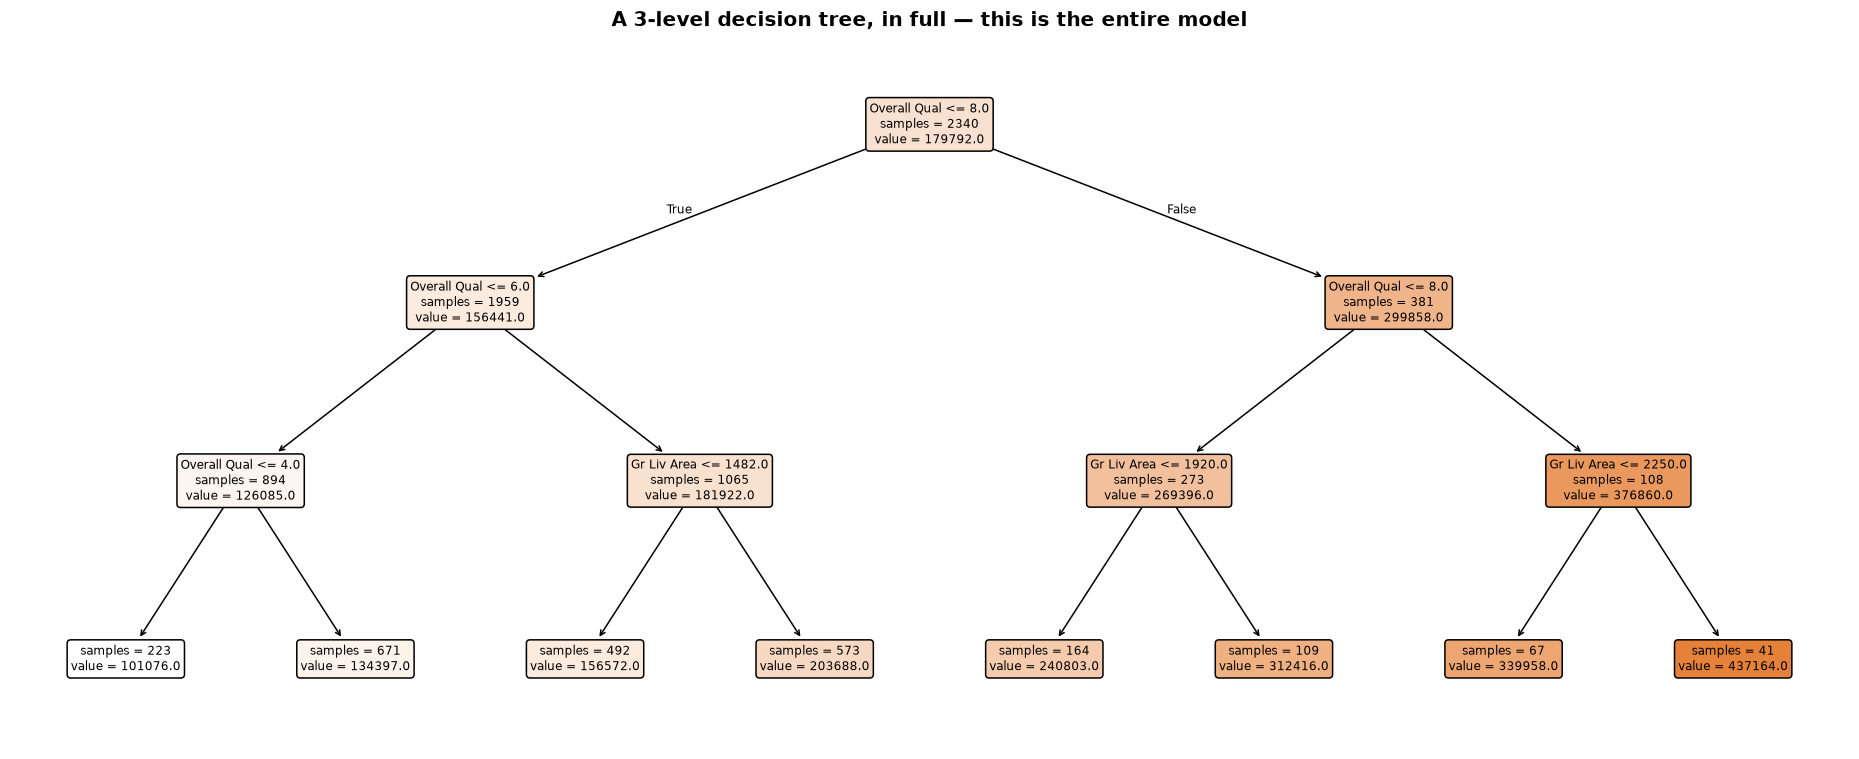

In [37]:
# Draw a small tree so you can read the actual logic.
readable = ["Overall Qual", "Gr Liv Area", "Year Built", "Total Bsmt SF", "Garage Cars"]
small = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
small.fit(X_train[readable].fillna(0), y_train)

plt.figure(figsize=(17, 7))
plot_tree(small, feature_names=readable, filled=True, rounded=True,
          fontsize=8, precision=0, impurity=False)
plt.title("A 3-level decision tree, in full — this is the entire model", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**What happened.** We trained a deliberately tiny tree on five readable columns and
drew it. This is not a summary of the model — **it is the model, complete**. Try that
with a neural network.

Reading a box: the top line is the question (`Overall Qual <= 7.5`). Go **left if
true**, right if false. `samples` is how many training houses reached that box; `value`
is the average price there, which is what the model predicts for anyone who lands in
that leaf. Darker boxes mean higher prices.

Follow the far-right path: high quality, big, and recently built → the most expensive
leaf. Follow the far-left: low quality, small → the cheapest. The model recovered basic
real-estate common sense from raw data, and can show its work.

**The catch:** trees are *unstable*. Change a handful of training rows and a top split
can flip, producing a completely different-looking tree. That fragility is what the
next model fixes.

---
# Part 11 — Model 9: Random Forest

### The idea in one sentence
**One tree is a fragile opinion. Grow 300 deliberately different trees and average
them.**

The trick is in *deliberately different*. If you grew 300 trees on the same data you'd
get 300 identical trees. So each tree is handicapped in two ways:

1. **Bagging** — each tree trains on a random sample of the rows, drawn with
   replacement. Every tree sees a slightly different dataset.
2. **Feature randomness** — at each split, a tree may only choose from a random subset
   of the features. This stops every tree from opening with "Overall Qual" and
   guarantees genuine diversity.

Each tree is now individually worse than a single well-tuned tree. But their *errors*
are uncorrelated, so when you average 300 predictions, the errors cancel and the signal
survives. This is the **wisdom of crowds**, and it works for the same reason: the crowd
must be diverse and independently wrong.

Random Forest is the model to reach for first on tabular data. It handles
non-linearity, interactions, mixed data types and outliers with essentially no tuning,
and it is very hard to make it overfit badly.

In [38]:
from sklearn.ensemble import RandomForestRegressor

model_9 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,        # grow 300 trees
        max_features=0.4,        # each split may consider 40% of features
        min_samples_leaf=2,      # a leaf must hold >=2 houses (also halves the file size)
        random_state=42,
        n_jobs=-1,               # use all CPU cores
    )),
])
model_9.fit(X_train, y_train)
y_pred_9 = model_9.predict(X_test)

score_model("9. Random Forest (300 trees)", y_test, y_pred_9, "Bagged ensemble", "09_random_forest")

9. Random Forest (300 trees) MAE $  14,217   RMSE $  22,342   R² 0.930


**What happened.** 300 trees grown and averaged, in a few seconds. `n_estimators=300`
is the crowd size — more is always at least as good, just slower, and gains flatten out
past a few hundred. `max_features=0.4` is the diversity knob.

**Compare it to Model 8:** the single pruned tree missed by about \$19,300; the forest
of 300 misses by about \$14,200, with no tuning search at all. Averaging noisy,
deliberately-handicapped trees beat carefully pruning one good one — that is the
ensemble effect in a single line.

It does *not* run away with the leaderboard here, though. Hold that thought until
Part 12; the ranking is going to be more interesting than you expect.

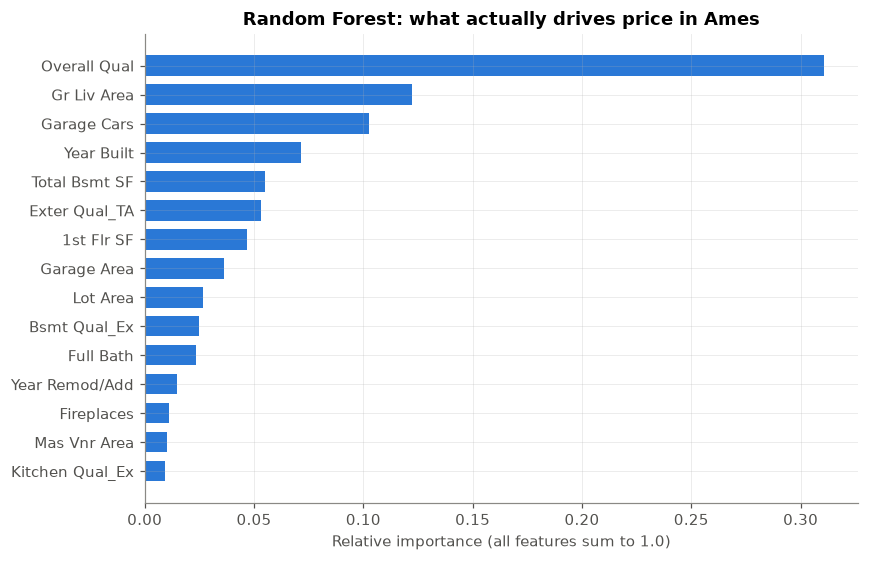

Top 5 features account for 66% of the model's decisions


In [39]:
# Which features does the forest actually rely on?
rf_names = model_9.named_steps["prep"].get_feature_names_out()
importances = pd.Series(model_9.named_steps["model"].feature_importances_, index=rf_names)
top15 = importances.sort_values(ascending=False)[:15][::-1]

plt.figure(figsize=(8, 5.2))
plt.barh(range(len(top15)), top15.values, color=BLUE, height=0.7)
plt.yticks(range(len(top15)), [n.split("__")[-1] for n in top15.index])
plt.xlabel("Relative importance (all features sum to 1.0)")
plt.title("Random Forest: what actually drives price in Ames")
plt.tight_layout(); plt.show()

print(f"Top 5 features account for {top15.values[-5:].sum():.0%} of the model's decisions")

**What happened.** `.feature_importances_` measures how much each feature reduced
prediction error across all 300 trees, normalised so the whole set sums to 1.

**Read the result as a finding, not a chart.** Overall Quality and living area dominate;
after that, garage capacity, basement size and age. The model — which was told nothing
about real estate — independently rediscovered how houses are actually valued.

**Two honest caveats.** This importance measure is biased toward features with many
possible split points, so continuous features tend to outrank one-hot columns. And it
shows *what the model used*, not *what causes price* — importance is not causation.
For serious work, follow up with permutation importance or SHAP values.

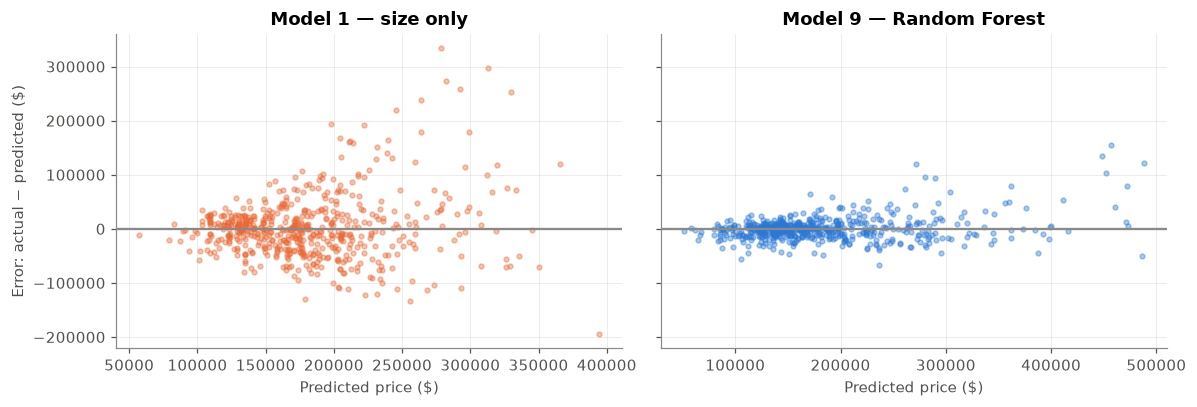

In [40]:
# Did the forest fix the pattern we saw in Model 1's residuals?
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (pred, name, col) in zip(axes, [(y_pred, "Model 1 — size only", ORANGE),
                                        (y_pred_9, "Model 9 — Random Forest", BLUE)]):
    ax.scatter(pred, y_test - pred, s=10, alpha=0.4, color=col)
    ax.axhline(0, color="#8a8985", linewidth=1.5)
    ax.set_xlabel("Predicted price ($)"); ax.set_title(name)
axes[0].set_ylabel("Error: actual − predicted ($)")
plt.tight_layout(); plt.show()

**What happened.** The same residual plot for our first and last models, on the same
vertical scale. The left cloud is wide and fans out; the right cloud is tight and much
flatter. The systematic under-pricing of expensive houses has largely gone.

Some spread remains at the top end, and it always will — a \$600,000 house sells for
reasons no spreadsheet column captures. Knowing where your model *stops* being reliable
is part of the deliverable.

---
# Part 12 — The showdown

Every model, side by side, scored on the same 585 houses none of them ever saw.

In [41]:
leaderboard = pd.DataFrame(results).sort_values("MAE ($)").reset_index(drop=True)
display_board = leaderboard.drop(columns=["key"]).copy()
display_board["MAE ($)"]  = display_board["MAE ($)"].map("${:,.0f}".format)
display_board["RMSE ($)"] = display_board["RMSE ($)"].map("${:,.0f}".format)
display_board["R²"]       = display_board["R²"].map("{:.3f}".format)
display_board

,Model,MAE ($),RMSE ($),R²,Note
0,4. Ridge (L2),"$13,829","$22,230",0.930,Polynomial + shrinkage
1,5. Lasso (L1),"$13,905","$21,661",0.934,Kept 83/245 features
2,6. Elastic Net (L1+L2),"$13,905","$21,661",0.934,l1_ratio=1.0
3,9. Random Forest (300 trees),"$14,217","$22,342",0.930,Bagged ensemble
4,3. Polynomial (degree 2),"$14,422","$24,002",0.919,Squares & interactions
5,2. Multiple Linear (27 feat),"$15,392","$23,701",0.921,All features
6,7. SVR (RBF kernel),"$15,396","$22,674",0.928,"C=10, epsilon=0.1"
7,8. Decision Tree (pruned),"$19,285","$28,036",0.889,depth=10
8,1. Simple Linear (1 feature),"$39,604","$58,520",0.518,Size only


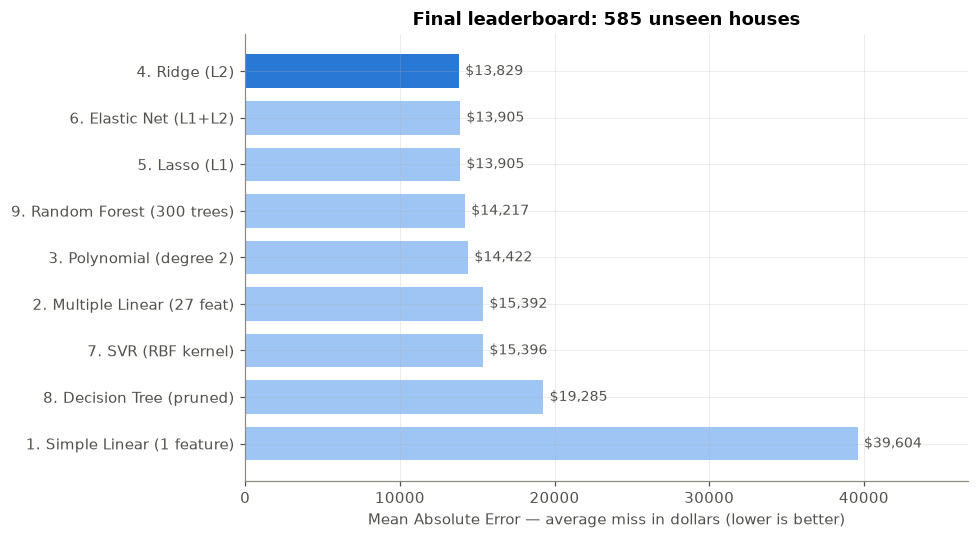

In [42]:
board = leaderboard.sort_values("MAE ($)", ascending=False)
plt.figure(figsize=(9, 5))
bars = plt.barh(range(len(board)), board["MAE ($)"],
                color=[BLUE if i == len(board) - 1 else "#9ec5f4" for i in range(len(board))],
                height=0.72)
plt.yticks(range(len(board)), board["Model"])
for i, v in enumerate(board["MAE ($)"]):
    plt.text(v + 400, i, f"${v:,.0f}", va="center", fontsize=9, color="#52514e")
plt.xlabel("Mean Absolute Error — average miss in dollars (lower is better)")
plt.title("Final leaderboard: 585 unseen houses")
plt.xlim(0, board["MAE ($)"].max() * 1.18)
plt.tight_layout(); plt.show()

**What happened.** We turned the `results` list into a DataFrame, sorted it, and drew
it. `.map("${:,.0f}".format)` is just formatting for display.

**What to take from the ranking:**

1. **The biggest jump by far was Model 1 → Model 2** — from about \$39,600 to \$15,400,
   achieved by *adding features*, not by changing the algorithm. Everything after that
   fought over the remaining \$2,000. **Feature work beats algorithm shopping**, and it
   is not close.
2. **The winners are regularised linear models, not the forest.** Ridge and Lasso on
   polynomial features take the top spots; Random Forest is a hair behind. If you came
   here expecting the fanciest model to win automatically, this is your correction: the
   right answer is empirical, and the only way to know is to run the comparison.
3. **Why did the linear models win here?** Because we handed them the non-linearity.
   `PolynomialFeatures` gave them squares and interactions, so their one real weakness
   was patched — and on 2,340 rows, a model with an actual functional form is more
   data-efficient than one that has to discover everything from splits.
4. **The pruned single tree came last of the serious models**, by a wide margin. One
   tree is a fragile opinion. That's the whole reason forests exist.
5. **Plain multiple linear regression is only about \$1,500/house behind the winner**,
   with no polynomial expansion, no tuning, and coefficients you can read aloud. In a
   regulated setting that is very often the model you should actually ship.

### Which model should you reach for?

| Model | Reach for it when | Avoid it when |
|---|---|---|
| **Simple Linear** | You need one interpretable relationship, or a sanity baseline | You have more than one thing worth knowing |
| **Multiple Linear** | You must explain every coefficient — finance, medicine, regulation | Relationships are strongly curved |
| **Polynomial** | You've seen curvature and have few features | You have many features (it explodes) |
| **Ridge** | Many correlated features; you want to keep them all | You need feature selection |
| **Lasso** | Many features, most probably useless; you want a shortlist | Correlated features you all want kept |
| **Elastic Net** | Both of the above — the safe default of the three | You need pure, unblended behaviour |
| **SVR** | Small-to-medium data, robustness to outliers matters | Big data (slow) or you must explain it |
| **Decision Tree** | You must *show* the logic to non-technical people | You need top accuracy (it's unstable) |
| **Random Forest** | Almost always, on tabular data. Start here — it tells you what score is achievable | You need a readable equation, or millisecond latency |

**A practical default:** start with a Random Forest to find out what score is
achievable, then fit a multiple linear regression and see how much you give up. If the
gap is small, ship the linear one — you can defend it.

---
# Part 13 — Saving the models and pricing a real house

A model that only exists inside a running notebook isn't an asset. Let's save all nine
to disk, then use one.

In [43]:
import joblib, os

os.makedirs("models", exist_ok=True)

trained = {
    "01_simple_linear":   model_1,
    "02_multiple_linear": model_2,
    "03_polynomial":      model_3,
    "04_ridge":           model_4,
    "05_lasso":           model_5,
    "06_elastic_net":     model_6,
    "07_svr":             model_7,
    "08_decision_tree":   model_8,
    "09_random_forest":   model_9,
}

for name, m in trained.items():
    joblib.dump(m, f"models/{name}.joblib", compress=3)   # compress=3 keeps the repo small
    size_kb = os.path.getsize(f"models/{name}.joblib") / 1024
    print(f"saved  models/{name}.joblib   ({size_kb:>8,.0f} KB)")

saved  models/01_simple_linear.joblib   (       1 KB)
saved  models/02_multiple_linear.joblib   (       4 KB)
saved  models/03_polynomial.joblib   (      10 KB)
saved  models/04_ridge.joblib   (       9 KB)
saved  models/05_lasso.joblib   (      10 KB)
saved  models/06_elastic_net.joblib   (      24 KB)
saved  models/07_svr.joblib   (     160 KB)
saved  models/08_decision_tree.joblib   (       8 KB)
saved  models/09_random_forest.joblib   (   7,576 KB)


**What happened.** `joblib.dump(object, path)` freezes a trained model — preprocessing
steps, learned medians, category lists, coefficients, all 300 trees — into a single
file. `os.makedirs(..., exist_ok=True)` creates the folder and doesn't complain if it
already exists.

Note the file sizes: the linear models are a few kilobytes because they *are* just a
list of numbers. The Random Forest is thousands of times bigger because it genuinely
contains 300 trees and every split in every one of them. `compress=3` squeezes them on
the way out — worth it when the file is going into a git repository.

**A word of caution for real use:** a `.joblib` file is executable Python under the
hood. Never load one from a source you don't trust, and be aware it is tied to the
library versions that created it. For production, pin your versions in
`requirements.txt` — which this repository does.

In [44]:
# Reload the winning model from disk, as a fresh program would, and price a house
# that appears nowhere in the dataset.
best_key  = leaderboard.iloc[0]["key"]
best_name = leaderboard.iloc[0]["Model"]
best_mae  = leaderboard.iloc[0]["MAE ($)"]
loaded = joblib.load(f"models/{best_key}.joblib")
print(f"Loaded the leaderboard winner: {best_name}\n")

new_house = pd.DataFrame([{
    "Gr Liv Area": 1800, "Total Bsmt SF": 900, "1st Flr SF": 1000, "Lot Area": 9000,
    "Overall Qual": 7, "Overall Cond": 5, "Year Built": 2001, "Year Remod/Add": 2001,
    "Garage Cars": 2, "Garage Area": 500, "Full Bath": 2, "Half Bath": 1,
    "TotRms AbvGrd": 7, "Fireplaces": 1, "Mas Vnr Area": 120,
    "Wood Deck SF": 150, "Open Porch SF": 40,
    "Neighborhood": "CollgCr", "House Style": "2Story", "Bldg Type": "1Fam",
    "Exter Qual": "Gd", "Kitchen Qual": "Gd", "Bsmt Qual": "Gd",
    "Heating QC": "Ex", "Central Air": "Y", "Foundation": "PConc",
    "Garage Type": "Attchd",
}])

estimate = loaded.predict(new_house)[0]
print(f"Estimated sale price:         ${estimate:,.0f}")
print(f"Typical error for this model: ± ${best_mae:,.0f}")

Loaded the leaderboard winner: 4. Ridge (L2)

Estimated sale price:         $210,612
Typical error for this model: ± $13,829


**What happened.** `leaderboard.iloc[0]` is the top row — the best model — and we
stored a filename key alongside every score precisely so this step could pick the
winner automatically instead of us hard-coding one. We loaded it, described one house
as a single-row DataFrame, and asked for a price. `[0]` pulls the single number out of
the returned array.

**Always quote the error alongside the estimate.** "\$205,000" is a false promise.
"\$205,000, typically accurate to within \$17,000" is a useful answer. A prediction
without an error bar is marketing, not analysis.

In [45]:
# Wrap it in a function, so the model becomes a tool anyone can use.
def price_a_house(model=None, **facts):
    """Price a house. Any fact you don't give is filled with the Ames median/most common."""
    if model is None:
        model = loaded                     # the leaderboard winner, loaded above
    row = {}
    for c in numeric_features:
        row[c] = houses[c].median()
    for c in categorical_features:
        row[c] = houses[c].mode()[0]
    row.update(facts)                       # your facts override the defaults
    return float(model.predict(pd.DataFrame([row]))[0])

for qual in [4, 6, 8, 10]:
    p = price_a_house(**{"Overall Qual": qual, "Gr Liv Area": 2000})
    print(f"2,000 sq ft, quality {qual:>2}  ->  ${p:>9,.0f}")

2,000 sq ft, quality  4  ->  $  164,589
2,000 sq ft, quality  6  ->  $  188,111
2,000 sq ft, quality  8  ->  $  213,898
2,000 sq ft, quality 10  ->  $  241,950


**What happened.** `price_a_house` fills every feature with a typical Ames value, then
lets you override whichever ones you care about. `**facts` collects any named arguments
you pass; `row.update(facts)` overwrites the defaults with them.

Look at the output: hold size fixed at 2,000 sq ft and walk quality from 4 to 10, and
the price climbs — but *not* in equal steps. Model 1, which only ever saw square
footage, could not have told you that quality is worth tens of thousands of dollars,
let alone that its value is uneven.

**One caveat worth teaching.** At quality 10 the model is extrapolating into thin air:
almost no 2,000 sq ft house in Ames was ever rated 10, so it has little to go on. Every
model is only trustworthy inside the range of data it saw. Ask it about a \$3m mansion
and it will still answer confidently, and it will still be wrong.

This little function is the closest thing here to a real product: a question anyone can
ask, answered by a model trained on 2,340 real sales.

---
# What you've actually built

You started with a CSV of 2,930 real house sales and no Python. You now have:

- **Nine trained, saved models**, each one a real file you can load anywhere.
- **An honest evaluation** of all nine on data none of them ever saw.
- **A working price estimator** that reports its own error.
- **A repository** you can put on GitHub as a portfolio piece.

And more importantly, the ideas underneath:

| Idea | Why it matters |
|---|---|
| **Train/test split** | The only honest score is on data the model has never seen |
| **Overfitting** | Any model flexible enough to memorise, will |
| **Regularisation** | Buy flexibility, but make the model pay for it |
| **Cross-validation** | Tune settings without ever touching the test set |
| **Pipelines** | Make data leakage structurally impossible |
| **Feature quality > algorithm choice** | The biggest win here came from better inputs |
| **Residual plots** | A pattern in the errors names the feature you forgot |
| **Interpretability vs. accuracy** | A real trade, made deliberately, not by default |

### Try these next

1. **Change `random_state=42` to another number** in the train/test split and re-run.
   Watch the scores move. That wobble is how much of your score is luck — and it's why
   a 0.002 R² improvement is not an improvement.
2. **Predict `log(SalePrice)` instead of `SalePrice`.** Prices are right-skewed;
   modelling the logarithm usually helps the linear models noticeably. Remember to
   exponentiate the predictions back before scoring in dollars.
3. **Add features we ignored.** There are 82 columns and we used 27. `Pool Area`,
   `Screen Porch`, `Sale Type` — do any of them earn their place?
4. **Try Gradient Boosting.** `from sklearn.ensemble import HistGradientBoostingRegressor`
   — one line to swap in, and on tabular data it usually edges out Random Forest.
5. **Break something on purpose.** Fit the scaler on the full dataset *before* splitting
   and see how much the test score inflates. Feeling data leakage is the fastest way to
   learn to fear it.

---

**Data source:** Dean De Cock, *"Ames, Iowa: Alternative to the Boston Housing Data as
an End of Semester Regression Project"*, Journal of Statistics Education, Vol. 19,
No. 3 (2011). Obtained via the `AmesHousing` R package (Max Kuhn).